In [1]:
%matplotlib widget

# Piecewise inversion

In [6]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling
from showStitched import showStitchedModels

In [3]:
norm = np.array([8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1])

# Load data

data_test = np.load('data/data_s1_c1_uc_sort.npy')[:40]*norm

# number of measurement positions 
npos = len(data_test)

In [10]:
# Setting forward operator 

fop = FDEM1DModelling(nlay=2)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000,2000/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)


In [16]:
# Perform inversion in each position

startModel = np.array([3, 0.5, 0.5])

model_est = []

for pos in range(npos):
    dat = data_test[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_est.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))

In [12]:
model_est = np.array(model_est)

<Axes: >

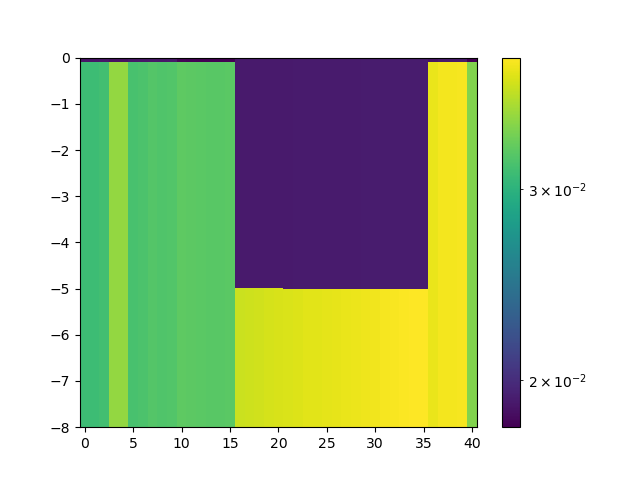

In [13]:
showStitchedModels(model_est, zMax=8)